In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.model_selection import GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor

In [2]:
df = pd.read_csv("NBA Player Stats and Salaries_2010-2025.csv")
print(df.head())
print(df.info())

             Player    Salary  Year Pos  Age Team   G  GS    MP   FG  ...  \
0       Kobe Bryant  23034375  2010  SG   31  LAL  73  73  38.8  9.8  ...   
1   Jermaine O'Neal  23016000  2010   C   31  MIA  70  70  28.4  5.6  ...   
2     Tracy McGrady  22843124  2010  SG   30  NYK  30  24  22.4  3.0  ...   
3        Tim Duncan  22183220  2010   C   33  SAS  78  77  31.3  7.2  ...   
4  Shaquille O'Neal  21000000  2010   C   37  CLE  53  53  23.4  4.9  ...   

     FT%  ORB  DRB   TRB  AST  STL  BLK  TOV   PF   PTS  
0  0.811  1.1  4.3   5.4  5.0  1.5  0.3  3.2  2.6  27.0  
1  0.720  1.8  5.2   6.9  1.3  0.4  1.4  1.8  3.0  13.6  
2  0.746  0.7  2.4   3.1  3.3  0.5  0.5  1.5  1.3   8.2  
3  0.725  2.8  7.3  10.1  3.2  0.6  1.5  1.8  1.9  17.9  
4  0.496  1.8  4.9   6.7  1.5  0.3  1.2  2.0  3.2  12.0  

[5 rows x 31 columns]
<class 'pandas.DataFrame'>
RangeIndex: 7298 entries, 0 to 7297
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  ----

In [3]:
categorical_cols = df.select_dtypes(include=['object']).columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns


print("Categorical Columns:", categorical_cols)
print("Numerical Columns:", numerical_cols)

Categorical Columns: Index(['Player', 'Pos', 'Team'], dtype='str')
Numerical Columns: Index(['Salary', 'Year', 'Age', 'G', 'GS', 'MP', 'FG', 'FGA', 'FG%', '3P',
       '3PA', '3P%', '2P', '2PA', '2P%', 'eFG%', 'FT', 'FTA', 'FT%', 'ORB',
       'DRB', 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS'],
      dtype='str')


C:\Users\Administrator\AppData\Local\Temp\ipykernel_17160\2932970109.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


In [4]:
print(df.isnull().sum())

Player      0
Salary      0
Year        0
Pos         0
Age         0
Team        0
G           0
GS          0
MP          0
FG          0
FGA         0
FG%        20
3P          0
3PA         0
3P%       585
2P          0
2PA         0
2P%        45
eFG%       20
FT          0
FTA         0
FT%       202
ORB         0
DRB         0
TRB         0
AST         0
STL         0
BLK         0
TOV         0
PF          0
PTS         0
dtype: int64


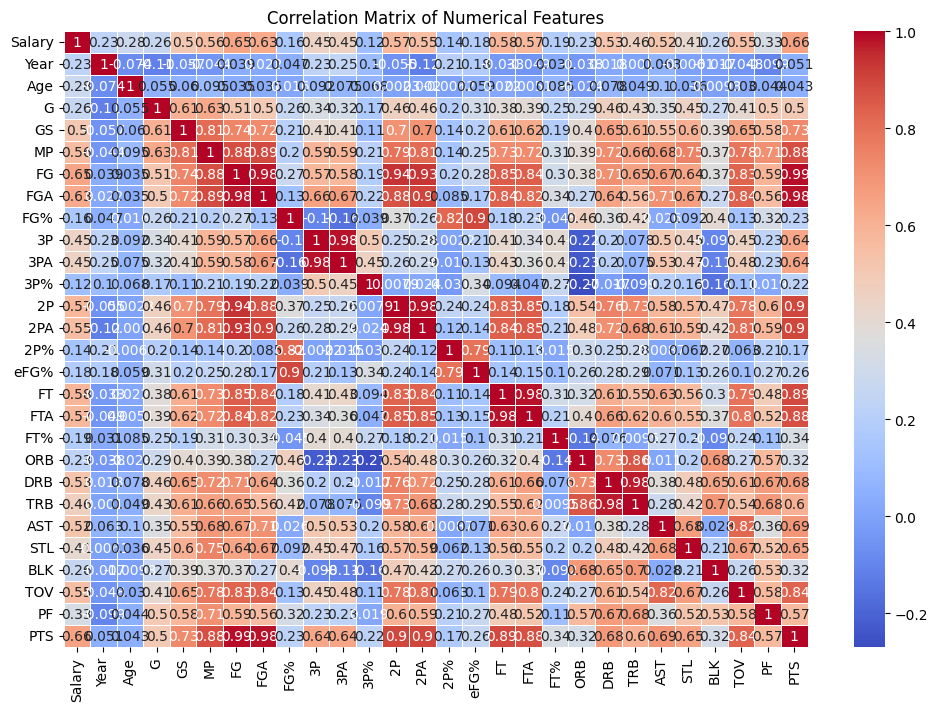

In [5]:
corr_matrix = df[numerical_cols].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [6]:
X = df.drop('Salary', axis=1)
y = df['Salary']

In [7]:
X_raw, X_test, y_raw, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
imputer = SimpleImputer(strategy='mean')
target = 'Salary'
numerical_cols = numerical_cols.drop(target)
X_raw_imputed = imputer.fit_transform(X_raw[numerical_cols])
X_test_imputed = imputer.transform(X_test[numerical_cols])


In [9]:
# 1. Setup DataFrames with proper column names
X_train_df = pd.DataFrame(X_raw_imputed, columns=numerical_cols)
X_test_df = pd.DataFrame(X_test_imputed, columns=numerical_cols)

# 2. Manual Selection: Define what to keep and what to remove immediately
# We drop "components" (like FG, FGA) to prevent them from "killing" the main stats (like PTS)
to_drop_manually = ['FG', 'FGA', '2P', '2PA', '3P', '3PA', 'ORB', 'DRB', 'FT', 'FTA', 'GS', 'G']
X_train_manual = X_train_df.drop(columns=to_drop_manually)

# 3. Define the VIF function
def calculate_vif(df):
    X_vif = add_constant(df)
    vif_list = []
    for i in range(X_vif.shape[1]):
        vif_list.append(variance_inflation_factor(X_vif.values, i))
    
    vif_data = pd.DataFrame({"feature": X_vif.columns, "VIF": vif_list})
    return vif_data[vif_data['feature'] != 'const'] # Return without the constant row

# 4. Recursive VIF Loop
# This loop cleans up whatever is left after your manual drop
thresh = 10.0
current_features = list(X_train_manual.columns)

print("Starting Recursive VIF Elimination...\n")
while True:
    vif_df = calculate_vif(X_train_manual[current_features])
    max_vif = vif_df['VIF'].max()
    
    if max_vif > thresh:
        # Identify the worst performing feature
        feature_to_drop = vif_df.sort_values('VIF', ascending=False)['feature'].iloc[0]
        
        # PRO-TIP: If the loop tries to drop 'PTS' or 'MP', you can add a check here to skip it
        if feature_to_drop in ['PTS', 'MP', 'TRB']:
            # If it's a star stat, we might stop here or drop the NEXT highest instead
            print(f"Holding onto '{feature_to_drop}' (VIF: {max_vif:.2f}) despite high correlation.")
            break 
            
        print(f"Dropping '{feature_to_drop}' with VIF: {max_vif:.2f}")
        current_features.remove(feature_to_drop)
    else:
        break

# 5. Finalize the Datasets
X_train_final = X_train_df[current_features]
X_test_final = X_test_df[current_features]

print("\nFinal Selected Features for Prediction:")
print(current_features)

Starting Recursive VIF Elimination...

Dropping 'FG%' with VIF: 11.99

Final Selected Features for Prediction:
['Year', 'Age', 'MP', '3P%', '2P%', 'eFG%', 'FT%', 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS']


In [10]:
# 1. Scale Numerical Data (and immediately convert to DataFrame with index)
scaler = StandardScaler()
X_train_scaled_df = pd.DataFrame(
    scaler.fit_transform(X_train_final), 
    columns=X_train_final.columns, 
    index=X_train_final.index
)
X_test_scaled_df = pd.DataFrame(
    scaler.transform(X_test_final), 
    columns=X_test_final.columns, 
    index=X_test_final.index
)

# 2. Encode Categorical Data
categorical_cols_to_use = [col for col in categorical_cols if col != 'Player']
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Fit/Transform and convert to DataFrame with matching index
X_train_cat_df = pd.DataFrame(
    ohe.fit_transform(X_raw[categorical_cols_to_use]),
    columns=ohe.get_feature_names_out(categorical_cols_to_use),
    index=X_train_final.index
)
X_test_cat_df = pd.DataFrame(
    ohe.transform(X_test[categorical_cols_to_use]),
    columns=ohe.get_feature_names_out(categorical_cols_to_use),
    index=X_test_final.index
)

# 3. Concatenate Everything
X_train_full = pd.concat([X_train_scaled_df, X_train_cat_df], axis=1)
X_test_full = pd.concat([X_test_scaled_df, X_test_cat_df], axis=1)

# Final Check
print(f"Final training shape: {X_train_full.shape}")
print(f"Any missing values? {X_train_full.isnull().sum().sum()}")


Final training shape: (5838, 62)
Any missing values? 0


In [11]:
lr = LinearRegression()
lr.fit(X_train_full, y_raw)
y_pred = lr.predict(X_test_full)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
accuracy_train = lr.score(X_train_full, y_raw)
accuracy_test = lr.score(X_test_full, y_test)
print(f"Mean Squared Error: {mse:.2f}")
print(f"R^2 Score: {r2:.4f}")
print(f"Training Accuracy: {accuracy_train:.4f}")
print(f"Testing Accuracy: {accuracy_test:.4f}")


Mean Squared Error: 28613693392864.38
R^2 Score: 0.5848
Training Accuracy: 0.5803
Testing Accuracy: 0.5848


In [12]:
scaler1 = StandardScaler()
X_train_scaled1 = scaler1.fit_transform(X_train_df)
X_test_scaled1 = scaler1.transform(X_test_df)

In [13]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled1, y_raw)
y_pred_ridge = ridge.predict(X_test_scaled1)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
print(f"Ridge Regression Mean Squared Error: {mse_ridge:.2f}")
r2_ridge = r2_score(y_test, y_pred_ridge)
print(f"Ridge Regression R^2 Score: {r2_ridge:.4f}")
accuracy_train_ridge = ridge.score(X_train_scaled1, y_raw)
accuracy_test_ridge = ridge.score(X_test_scaled1, y_test)
print(f"Ridge Regression Training Accuracy: {accuracy_train_ridge:.4f}")
print(f"Ridge Regression Testing Accuracy: {accuracy_test_ridge:.4f}")

Ridge Regression Mean Squared Error: 27328308240289.35
Ridge Regression R^2 Score: 0.6034
Ridge Regression Training Accuracy: 0.5861
Ridge Regression Testing Accuracy: 0.6034


In [14]:
lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled1, y_raw)
y_pred_lasso = lasso.predict(X_test_scaled1)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
print(f"Lasso Regression Mean Squared Error: {mse_lasso:.2f}")
r2_lasso = r2_score(y_test, y_pred_lasso)
print(f"Lasso Regression R^2 Score: {r2_lasso:.4f}")
accuracy_train_lasso = lasso.score(X_train_scaled1, y_raw)
accuracy_test_lasso = lasso.score(X_test_scaled1, y_test)
print(f"Lasso Regression Training Accuracy: {accuracy_train_lasso:.4f}")
print(f"Lasso Regression Testing Accuracy: {accuracy_test_lasso:.4f}")



Lasso Regression Mean Squared Error: 27333019091758.51
Lasso Regression R^2 Score: 0.6033
Lasso Regression Training Accuracy: 0.5859
Lasso Regression Testing Accuracy: 0.6033


c:\Users\Administrator\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.969e+16, tolerance: 4.332e+13
  model = cd_fast.enet_coordinate_descent(


In [15]:
regr_vif = RandomForestRegressor(max_depth=2, random_state=0)
regr_vif.fit(X_train_full, y_raw)
y_pred_rf = regr_vif.predict(X_test_full)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)
print(f"Random Forest Mean Squared Error: {mse_rf:.2f}")
print(f"Random Forest R^2 Score: {r2_rf:.4f}")
accuracy_train_rf = regr_vif.score(X_train_full, y_raw)
accuracy_test_rf = regr_vif.score(X_test_full, y_test)
print(f"Random Forest Training Accuracy: {accuracy_train_rf:.4f}")
print(f"Random Forest Testing Accuracy: {accuracy_test_rf:.4f}")

Random Forest Mean Squared Error: 33037558534182.14
Random Forest R^2 Score: 0.5206
Random Forest Training Accuracy: 0.5160
Random Forest Testing Accuracy: 0.5206


In [16]:
regr = RandomForestRegressor(max_depth=2, random_state=0)
regr.fit(X_train_scaled1, y_raw)
y_pred_rf = regr.predict(X_test_scaled1)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)
print(f"Random Forest (Scaled) Mean Squared Error: {mse_rf:.2f}")
print(f"Random Forest (Scaled) R^2 Score: {r2_rf:.4f}")
accuracy_train_rf_scaled = regr.score(X_train_scaled1, y_raw)
accuracy_test_rf_scaled = regr.score(X_test_scaled1, y_test)
print(f"Random Forest (Scaled) Training Accuracy: {accuracy_train_rf_scaled:.4f}")
print(f"Random Forest (Scaled) Testing Accuracy: {accuracy_test_rf_scaled:.4f}")


Random Forest (Scaled) Mean Squared Error: 33029224493670.58
Random Forest (Scaled) R^2 Score: 0.5207
Random Forest (Scaled) Training Accuracy: 0.5164
Random Forest (Scaled) Testing Accuracy: 0.5207


In [17]:
xgb_vif = XGBRegressor(objective='reg:squarederror', random_state=42)
xgb_vif.fit(X_train_full, y_raw)
y_pred_xgb_vif = xgb_vif.predict(X_test_full)
mse_xgb_vif = mean_squared_error(y_test, y_pred_xgb_vif)
r2_xgb_vif = r2_score(y_test, y_pred_xgb_vif)
print(f"XGBoost VIF Mean Squared Error: {mse_xgb_vif:.2f}")
print(f"XGBoost VIF R^2 Score: {r2_xgb_vif:.4f}")
accuracy_train_xgb_vif = xgb_vif.score(X_train_full, y_raw)
accuracy_test_xgb_vif = xgb_vif.score(X_test_full, y_test)
print(f"XGBoost VIF Training Accuracy: {accuracy_train_xgb_vif:.4f}")
print(f"XGBoost VIF Testing Accuracy: {accuracy_test_xgb_vif:.4f}")

XGBoost VIF Mean Squared Error: 18963736035328.00
XGBoost VIF R^2 Score: 0.7248
XGBoost VIF Training Accuracy: 0.9685
XGBoost VIF Testing Accuracy: 0.7248


In [18]:
xgb = XGBRegressor(objective='reg:squarederror', random_state=42)
xgb.fit(X_train_scaled1, y_raw)
y_pred_xgb = xgb.predict(X_test_scaled1)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)
print(f"XGBoost Mean Squared Error: {mse_xgb:.2f}")
print(f"XGBoost R^2 Score: {r2_xgb:.4f}")
accuracy_train_xgb = xgb.score(X_train_scaled1, y_raw)
accuracy_test_xgb = xgb.score(X_test_scaled1, y_test)
print(f"XGBoost Training Accuracy: {accuracy_train_xgb:.4f}")
print(f"XGBoost Testing Accuracy: {accuracy_test_xgb:.4f}")



XGBoost Mean Squared Error: 19559809548288.00
XGBoost R^2 Score: 0.7162
XGBoost Training Accuracy: 0.9796
XGBoost Testing Accuracy: 0.7162


In [19]:
xgb_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0]
}
grid_search = GridSearchCV(estimator=XGBRegressor(objective='reg:squarederror', random_state=42), param_grid=xgb_param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_train_full, y_raw)
print(f"Best XGBoost Parameters: {grid_search.best_params_}")
print(f"Best XGBoost Cross-Validation Score: {grid_search.best_score_:.4f}")

Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best XGBoost Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.8}
Best XGBoost Cross-Validation Score: 0.7332


In [20]:
mse_xgb_tuned = mean_squared_error(y_test, grid_search.predict(X_test_full))
r2_xgb_tuned = r2_score(y_test, grid_search.predict(X_test_full))
print(f"Tuned XGBoost Mean Squared Error: {mse_xgb_tuned:.2f}")
print(f"Tuned XGBoost R^2 Score: {r2_xgb_tuned:.4f}")
accuracy_train_xgb_tuned = grid_search.score(X_train_full, y_raw)
accuracy_test_xgb_tuned = grid_search.score(X_test_full, y_test)
print(f"Tuned XGBoost Training Accuracy: {accuracy_train_xgb_tuned:.4f}")
print(f"Tuned XGBoost Testing Accuracy: {accuracy_test_xgb_tuned:.4f}")

Tuned XGBoost Mean Squared Error: 17481867460608.00
Tuned XGBoost R^2 Score: 0.7463
Tuned XGBoost Training Accuracy: 0.8739
Tuned XGBoost Testing Accuracy: 0.7463


In [21]:
xgb_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0]
}
grid_search = GridSearchCV(estimator=XGBRegressor(objective='reg:squarederror', random_state=42), param_grid=xgb_param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_train_scaled1, y_raw)
print(f"Best XGBoost Parameters: {grid_search.best_params_}")
print(f"Best XGBoost Cross-Validation Score: {grid_search.best_score_:.4f}")

Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best XGBoost Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'subsample': 1.0}
Best XGBoost Cross-Validation Score: 0.7292


In [22]:
mse_xgb_tuned = mean_squared_error(y_test, grid_search.predict(X_test_scaled1))
r2_xgb_tuned = r2_score(y_test, grid_search.predict(X_test_scaled1))
print(f"Tuned XGBoost (Scaled) Mean Squared Error: {mse_xgb_tuned:.2f}")
print(f"Tuned XGBoost (Scaled) R^2 Score: {r2_xgb_tuned:.4f}")
accuracy_train_xgb_tuned = grid_search.score(X_train_scaled1, y_raw)    
accuracy_test_xgb_tuned = grid_search.score(X_test_scaled1, y_test)
print(f"Tuned XGBoost (Scaled) Training Accuracy: {accuracy_train_xgb_tuned:.4f}")
print(f"Tuned XGBoost (Scaled) Testing Accuracy: {accuracy_test_xgb_tuned:.4f}")

Tuned XGBoost (Scaled) Mean Squared Error: 17140413366272.00
Tuned XGBoost (Scaled) R^2 Score: 0.7513
Tuned XGBoost (Scaled) Training Accuracy: 0.8835
Tuned XGBoost (Scaled) Testing Accuracy: 0.7513


In [24]:
# Pipeline based on the best-performing tuned XGBoost setup
best_params = grid_search.best_params_

best_model_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('xgb', XGBRegressor(
        objective='reg:squarederror',
        random_state=42,
        **best_params
    ))
])

best_model_pipeline.fit(X_train_df, y_raw)

y_pred_best_pipeline = best_model_pipeline.predict(X_test_df)

mse_best_pipeline = mean_squared_error(y_test, y_pred_best_pipeline)
r2_best_pipeline = r2_score(y_test, y_pred_best_pipeline)
accuracy_train_best_pipeline = best_model_pipeline.score(X_train_df, y_raw)
accuracy_test_best_pipeline = best_model_pipeline.score(X_test_df, y_test)

print(f"Best Pipeline Params: {best_params}")
print(f"Best Pipeline Mean Squared Error: {mse_best_pipeline:.2f}")
print(f"Best Pipeline R^2 Score: {r2_best_pipeline:.4f}")
print(f"Best Pipeline Training Accuracy: {accuracy_train_best_pipeline:.4f}")
print(f"Best Pipeline Testing Accuracy: {accuracy_test_best_pipeline:.4f}")

Best Pipeline Params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'subsample': 1.0}
Best Pipeline Mean Squared Error: 17140413366272.00
Best Pipeline R^2 Score: 0.7513
Best Pipeline Training Accuracy: 0.8835
Best Pipeline Testing Accuracy: 0.7513


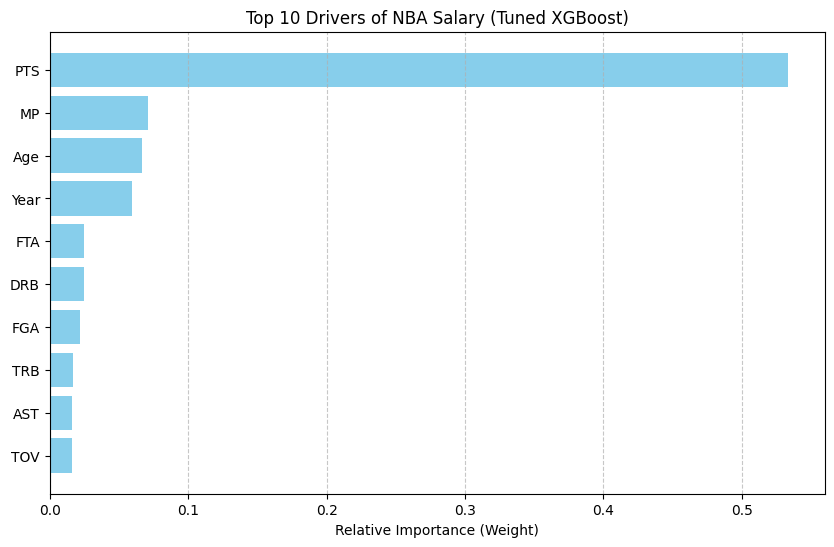

In [28]:
model = best_model_pipeline.named_steps['xgb'] 

# 2. Get the importance from the model
importances = model.feature_importances_

# 3. Use the correct feature names (X_train_full has the OHE columns too)
feat_names = X_train_df.columns
indices = np.argsort(importances)[-10:] # Top 10

# 4. Plot
plt.figure(figsize=(10,6))
plt.title("Top 10 Drivers of NBA Salary (Tuned XGBoost)")
plt.barh(range(len(indices)), importances[indices], color='skyblue', align='center')
plt.yticks(range(len(indices)), [feat_names[i] for i in indices])
plt.xlabel('Relative Importance (Weight)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()
